# EduTech Perú — Análisis exploratorio

Este notebook documenta la fase de comprensión de los datos: qué hay, qué está
roto, qué forma tiene la relación entre comportamiento y deserción, y qué
implica todo eso para las decisiones de modelamiento que se toman después.

El orden importa: primero se mira el dato crudo tal como llega, después se
limpia, y recién al final se parte. Cualquier estadístico que se calcule sobre
el conjunto completo y se use para transformar (una mediana, una media, una
codificación) tiene que quedar dentro del pipeline de entrenamiento, nunca acá.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src.preprocessing import limpiar, agregar_features, particion_temporal

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})


## 1. El dato crudo


In [2]:
crudo = pd.read_csv(C.DATA_RAW / "edutech_desercion_raw.csv")
print(f"{crudo.shape[0]:,} filas x {crudo.shape[1]} columnas")
crudo.head()


9,028 filas x 16 columnas


,EstudianteID,CohorteMes,TenureSemanas,Edad,CategoriaCurso,Modalidad,MetodoPago,HorasUsoSemana,PctTareasATiempo,PromedioNotas,ParticipacionForo,QuejasSoporte,DiasUltimaSesion,TieneBecaDescuento,CursosPreviosCompletados,Desercion
0,2240,2026-04,5,26,Idiomas,Autoestudio,Tarjeta de crédito,3.5,72.6,12.7,2,0,4,0,0,0
1,8496,2025-01,6,25,Idiomas,Con mentor en vivo,Débito,9.1,66.4,15.5,5,0,6,0,0,0
2,7221,2025-07,4,35,Idiomas,Autoestudio,Transferencia,2.1,49.5,12.8,1,0,2,0,1,1
3,8432,2025-04,4,25,Finanzas,Autoestudio,Yape/Plin,6.9,77.7,13.8,3,0,5,0,1,0
4,4708,2025-10,5,28,Diseño,Autoestudio,Tarjeta de crédito,2.1,83.0,16.6,5,0,5,0,2,0


In [3]:
resumen = pd.DataFrame({
    "tipo": crudo.dtypes.astype(str),
    "nulos": crudo.isna().sum(),
    "% nulos": (crudo.isna().mean() * 100).round(2),
    "valores únicos": crudo.nunique(),
})
resumen


,tipo,nulos,% nulos,valores únicos
EstudianteID,int64,0,0.00,9000
CohorteMes,str,0,0.00,18
TenureSemanas,int64,0,0.00,40
Edad,int64,0,0.00,42
CategoriaCurso,str,0,0.00,5
Modalidad,str,0,0.00,4
MetodoPago,str,0,0.00,4
HorasUsoSemana,float64,150,1.66,183
PctTareasATiempo,float64,0,0.00,910
PromedioNotas,float64,513,5.68,155


### Problemas de calidad detectados

Antes de tocar nada conviene inventariar lo que está mal. Los cuatro problemas
que aparecen abajo son los que motivan cada paso de `src/preprocessing.limpiar`.


In [4]:
print("Duplicados por EstudianteID:", int(crudo["EstudianteID"].duplicated().sum()))
print("Categorías de Modalidad:", sorted(crudo["Modalidad"].unique()))
print("Edades fuera de rango [15, 80]:", int((~crudo["Edad"].between(15, 80)).sum()))
print("\nNulos por columna:")
print(crudo.isna().sum()[lambda s: s > 0])


Duplicados por EstudianteID: 28
Categorías de Modalidad: ['AUTOESTUDIO', 'Autoestudio', 'CON MENTOR EN VIVO', 'Con mentor en vivo']
Edades fuera de rango [15, 80]: 15

Nulos por columna:
HorasUsoSemana    150
PromedioNotas     513
dtype: int64


### Los nulos de `PromedioNotas` no son aleatorios

Este es el hallazgo más importante de la exploración. Si el dato faltara al
azar, la tasa de deserción sería parecida entre quienes tienen nota y quienes
no. No lo es: **falta justamente en los estudiantes que ya se desconectaron**,
porque nunca llegaron a rendir evaluaciones.

Consecuencia práctica: imputar por la mediana y seguir de largo borra una señal
fuerte. Hay que imputar **y además** crear un indicador de que el dato faltaba.


In [5]:
crudo["_falta_nota"] = crudo["PromedioNotas"].isna()
print(crudo.groupby("_falta_nota").agg(
    n=("Desercion", "size"),
    tasa_desercion=("Desercion", "mean"),
    dias_inactividad_medios=("DiasUltimaSesion", "mean"),
).round(3))
crudo = crudo.drop(columns="_falta_nota")


                n  tasa_desercion  dias_inactividad_medios
_falta_nota                                               
False        8515           0.181                    5.586
True          513           0.448                   18.897


## 2. Limpieza y variables derivadas


In [6]:
df = agregar_features(limpiar(crudo))
print(f"\n{df.shape[0]:,} filas x {df.shape[1]} columnas tras limpieza y feature engineering")


Limpieza:
  duplicados_eliminados            28
  edades_invalidas                 15
  fuera_de_rango_PctTareasATiempo  0
  fuera_de_rango_PromedioNotas     0
  fuera_de_rango_DiasUltimaSesion  0
  fuera_de_rango_HorasUsoSemana    0
  nulos_totales                    674
  filas_finales                    9000

9,000 filas x 23 columnas tras limpieza y feature engineering


## 3. La variable objetivo


Tasa de deserción: 19.6%
Un clasificador que diga 'nadie deserta' acertaría el 80.4% de las veces.
Por eso accuracy no sirve como métrica de este problema.


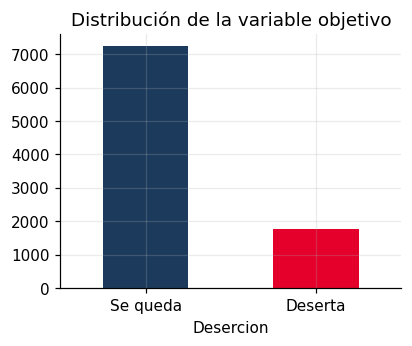

In [7]:
tasa = df[C.TARGET].mean()
print(f"Tasa de deserción: {tasa:.1%}")
print(f"Un clasificador que diga 'nadie deserta' acertaría el {1-tasa:.1%} de las veces.")
print("Por eso accuracy no sirve como métrica de este problema.")

fig, ax = plt.subplots(figsize=(4, 3))
df[C.TARGET].value_counts().plot.bar(ax=ax, color=[C.PALETA["primario"], C.PALETA["acento"]])
ax.set_xticklabels(["Se queda", "Deserta"], rotation=0)
ax.set_title("Distribución de la variable objetivo")
plt.show()


## 4. Drift temporal

La tasa de deserción no es estable: sube de forma sostenida a lo largo de las
18 cohortes. Eso invalida el split aleatorio, porque mezclaría cohortes de 2025
y 2026 en entrenamiento y prueba y daría una foto optimista de lo que el modelo
hará en producción.


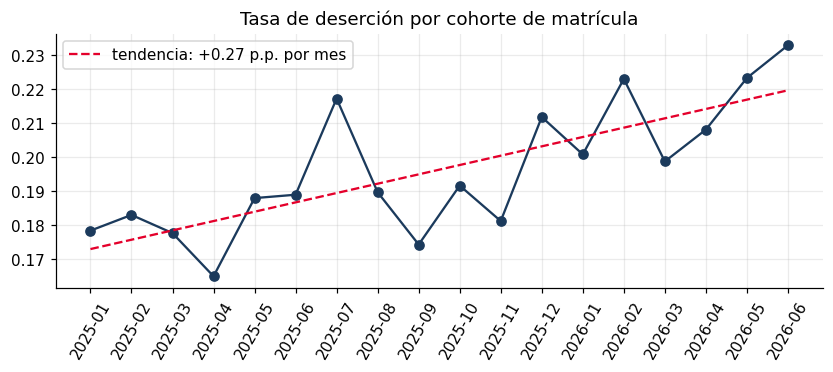

In [8]:
agg = df.groupby(C.COL_COHORTE)[C.TARGET].agg(["size", "mean"])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(agg.index, agg["mean"], "o-", color=C.PALETA["primario"])
z = np.polyfit(np.arange(len(agg)), agg["mean"], 1)
ax.plot(agg.index, np.poly1d(z)(np.arange(len(agg))), "--", color=C.PALETA["acento"],
        label=f"tendencia: {z[0]*100:+.2f} p.p. por mes")
ax.set_title("Tasa de deserción por cohorte de matrícula")
ax.legend(); plt.xticks(rotation=60); plt.show()


## 5. Qué forma tiene la relación con la deserción

Acá está la justificación empírica de por qué se comparan modelos lineales
contra modelos de árboles. Si las relaciones fueran rectas, la regresión
logística bastaría. Mirá las dos primeras: no lo son.

- **Días sin ingresar**: el riesgo es plano hasta los ~10 días y ahí se dispara.
  Un modelo lineal tiene que elegir entre ajustar bien la zona plana o la zona
  empinada, y no puede hacer las dos.
- **Semanas en el curso**: forma de bañera. Alto al inicio (onboarding), bajo
  en el medio, y vuelve a subir cerca del final. Una pendiente única no puede
  representar una curva que primero baja y después sube.


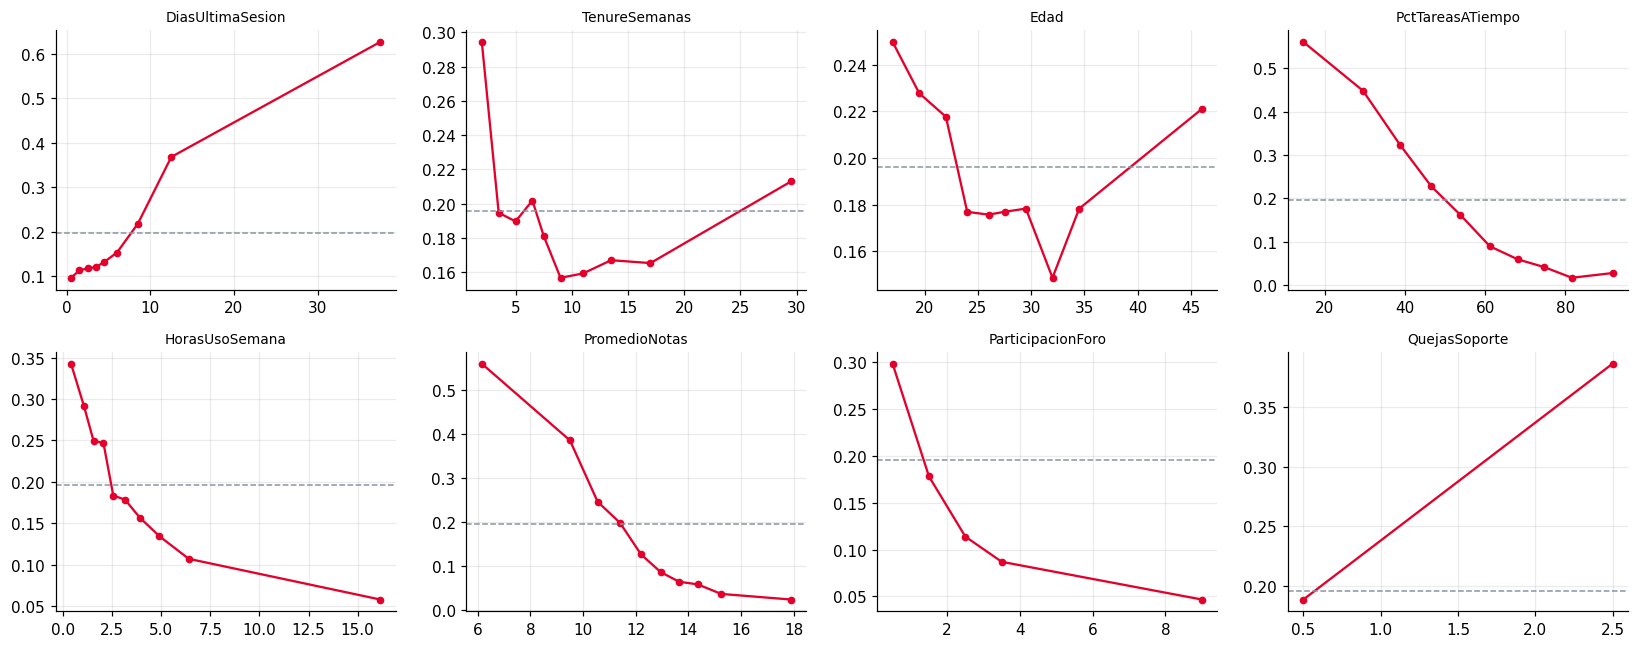

In [9]:
variables = ["DiasUltimaSesion", "TenureSemanas", "Edad", "PctTareasATiempo",
             "HorasUsoSemana", "PromedioNotas", "ParticipacionForo", "QuejasSoporte"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, var in zip(axes.ravel(), variables):
    d = df[[var, C.TARGET]].dropna()
    tramos = pd.qcut(d[var], 10, duplicates="drop")
    g = d.groupby(tramos, observed=True)[C.TARGET].mean()
    ax.plot([iv.mid for iv in g.index], g.values, "o-", color=C.PALETA["acento"], ms=4)
    ax.axhline(tasa, color=C.PALETA["gris"], ls="--", lw=1)
    ax.set_title(var, fontsize=9)
plt.tight_layout(); plt.show()


### Interacciones

El riesgo de la modalidad autoestudio no es el mismo para todos: depende de si
el estudiante participa o no en la comunidad. Cuando el efecto de una variable
cambia según el valor de otra, un modelo aditivo necesita que alguien le
escriba el término de interacción a mano; los árboles lo encuentran solos.


                     mean         size     
SinComunidad            0      1     0    1
Modalidad                                  
Autoestudio         0.204  0.482  4622  993
Con mentor en vivo  0.086  0.198  2936  449


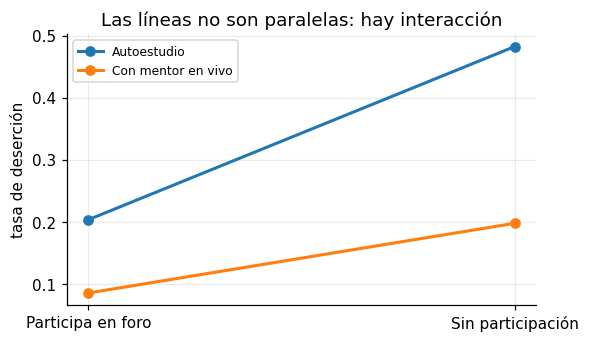

In [10]:
tabla = df.pivot_table(index="Modalidad", columns="SinComunidad",
                       values=C.TARGET, aggfunc=["mean", "size"])
print(tabla.round(3))

fig, ax = plt.subplots(figsize=(5.5, 3.2))
for i, (mod, sub) in enumerate(df.groupby("Modalidad")):
    g = sub.groupby("SinComunidad")[C.TARGET].mean()
    ax.plot([0, 1], g.values, "o-", lw=2, label=mod)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Participa en foro", "Sin participación"])
ax.set_ylabel("tasa de deserción")
ax.set_title("Las líneas no son paralelas: hay interacción")
ax.legend(fontsize=8); plt.show()


## 6. Correlaciones

Las variables de comportamiento están correlacionadas entre sí porque todas
miden lo mismo por debajo: el nivel de compromiso del estudiante. Eso importa
para la interpretación de los coeficientes de un modelo lineal, no para su
capacidad predictiva.


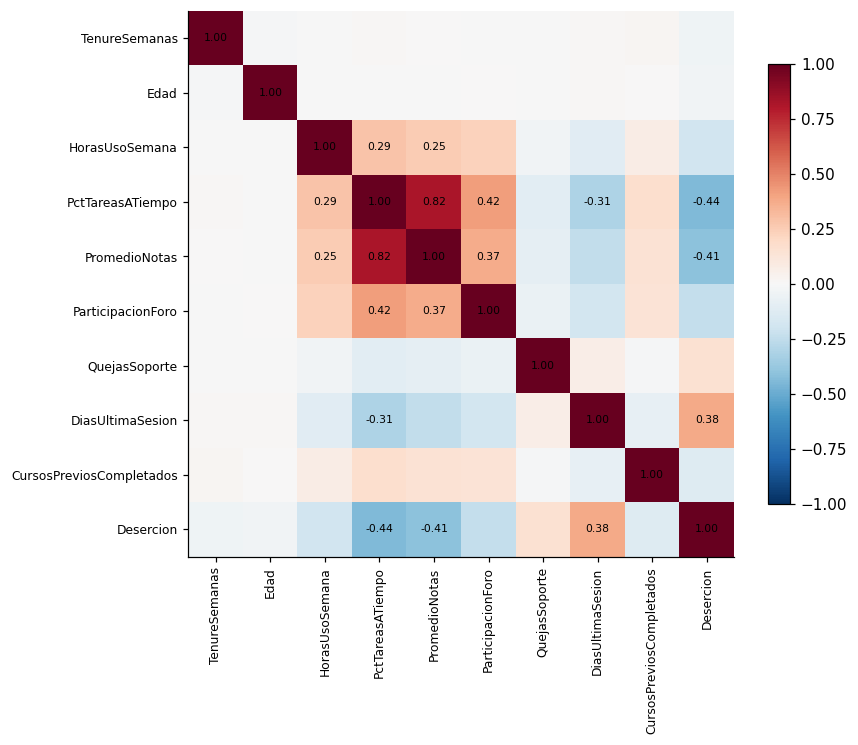


Correlación con la deserción, de mayor a menor:
PctTareasATiempo           -0.442
PromedioNotas              -0.412
DiasUltimaSesion            0.381
ParticipacionForo          -0.242
HorasUsoSemana             -0.189
QuejasSoporte               0.149
CursosPreviosCompletados   -0.126
TenureSemanas              -0.041
Edad                       -0.035
Name: Desercion, dtype: float64


In [11]:
corr = df[C.NUMERICAS + [C.TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        if abs(corr.iloc[i, j]) > 0.25:
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.grid(False); plt.colorbar(im, shrink=0.8); plt.show()

print("\nCorrelación con la deserción, de mayor a menor:")
print(corr[C.TARGET].drop(C.TARGET).sort_values(key=abs, ascending=False).round(3))


## 7. Partición temporal

Las 11 primeras cohortes entrenan, las 3 siguientes sirven para calibrar y
elegir el umbral, y las 4 últimas se reservan como prueba out-of-time. Nótese
que la tasa de deserción sube de partición en partición: el modelo va a
enfrentar en prueba una población algo distinta a la que vio al entrenar, que
es exactamente lo que pasa en producción.


In [12]:
train, valid, test = particion_temporal(df)


  train:  5584 filas | cohortes 2025-01 a 2025-11 | deserción 18.5%
  valid:  1460 filas | cohortes 2025-12 a 2026-02 | deserción 21.2%
  test :  1956 filas | cohortes 2026-03 a 2026-06 | deserción 21.6%


## Conclusiones de la exploración

1. **Accuracy queda descartada** como métrica: con 20% de deserción, no hacer
   nada acierta el 80%.
2. **El faltante de `PromedioNotas` es informativo** y se agrega como variable
   propia (`NotaFaltante`), además de imputarse.
3. **Las relaciones no son lineales** (efecto umbral en inactividad, curva de
   bañera en permanencia) y **hay interacciones** (modalidad × comunidad). Eso
   justifica comparar modelos de árboles y red neuronal contra la regresión
   logística en vez de asumir cuál gana.
4. **Hay drift temporal**, así que la validación tiene que ser out-of-time.
5. **La imputación y el escalado van dentro del pipeline**, ajustados solo con
   entrenamiento, para no filtrar información de las particiones de evaluación.
